# Phase 4: Extending to Three Dimensions

Every phase so far has lived in a flat, 2D orbital plane. Real orbits don't — a satellite's path is tilted in three-dimensional space, and a telescope on the ground doesn't see a 2D map of that path. It sees a flat image: a single 2D pixel position representing something that's actually moving through 3D.

This phase rebuilds the full pipeline — physics-informed prediction, vision-based observation, and Kalman filter fusion — in 3D, and in doing so runs into a problem the earlier phases didn't have to face:

**A camera image only tells you a direction, not a distance.**

Point a telescope at a satellite, and the image tells you *which way* to look — but not *how far away* the satellite is along that line of sight. Two very different 3D positions can produce the exact same pixel in the image, as long as they're both along the same ray from the camera.

This is where the project's core idea — physics and vision correcting each other — gets to prove itself for real. The vision model will supply *direction* (bearing), and the physics-informed model will supply a prior on *distance* (depth) from its own trajectory prediction. The Extended Kalman Filter is what reconciles the two into a single 3D position estimate — and this time, the "Extended" part of the EKF is doing genuine work, because projecting a 3D point into a 2D image is a nonlinear operation with no shortcut around it.

![Depth ambiguity: two different 3D points can land on the same pixel](../images/depth_ambiguity_concept.png)

## Step 1: Simulating a Real 3D Orbit

In 2D, an orbit was fully described by position (x, y) and velocity (vx, vy). In 3D, we add a z-axis, and the orbit no longer has to lie flat — it can be *inclined*, tilted at an angle relative to our chosen reference plane, the way real satellite orbits actually are.

The physics doesn't get more complicated — it's still Newton's law of gravitation, just with one more dimension. The interesting part is that we'll deliberately choose an inclined, tilted orbit (not a flat one) so the 3D visualizations actually look three-dimensional, and so the depth-ambiguity problem from the intro is real and not just theoretical.

In [2]:
import numpy as np          # numerical arrays and math (sqrt, linspace, etc.)
import torch                # building and training the 3D PINN
import torch.nn as nn       # neural network layers
from torch.autograd.functional import jacobian   # EKF Jacobian computation later in this notebook
import matplotlib.pyplot as plt                  # 2D plotting
from mpl_toolkits.mplot3d import Axes3D          # enables 3D plotting
from scipy.integrate import solve_ivp            # numerically solves the 3D orbital equations

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Numerically integrates the 3D two-body problem to produce a trusted ground-truth orbit
from scipy.integrate import solve_ivp

def two_body_3d(t, state, GM=1.0):
    x, y, z, vx, vy, vz = state
    r = np.sqrt(x**2 + y**2 + z**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    az = -GM * z / r**3
    return [vx, vy, vz, ax, ay, az]

GM = 1.0

# Initial state: deliberately tilted out of the xy-plane so the orbit is genuinely 3D
initial_state_3d = [1.0, 0.0, 0.0, 0.0, 0.7, 0.3]

t_span = (0, 20)
t_eval = np.linspace(*t_span, 2000)

solution_3d = solve_ivp(
    two_body_3d, t_span, initial_state_3d, t_eval=t_eval,
    args=(GM,), method="DOP853", rtol=1e-10, atol=1e-10
)

x_true_3d, y_true_3d, z_true_3d = solution_3d.y[0], solution_3d.y[1], solution_3d.y[2]

print(f"3D orbit simulated: {len(t_eval)} points over t in {t_span}")
print(f"z ranges from {z_true_3d.min():.3f} to {z_true_3d.max():.3f} — confirms the orbit is genuinely tilted out of plane")

3D orbit simulated: 2000 points over t in (0, 20)
z ranges from -0.252 to 0.252 — confirms the orbit is genuinely tilted out of plane


## Visualizing the 3D Orbit

Here's what that tilted orbit actually looks like in three dimensions. The plot is interactive — in VS Code / Jupyter, you can click and drag to rotate it and see the tilt from different angles.

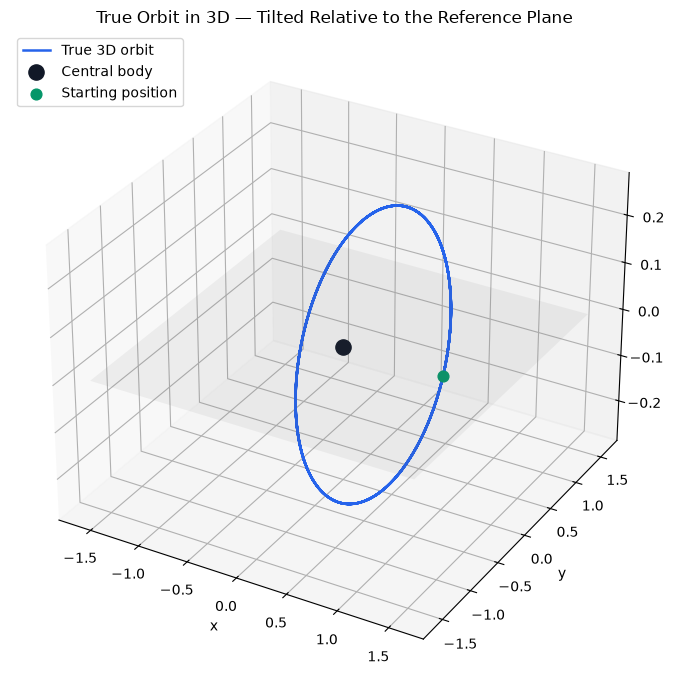

In [4]:
# Renders the true 3D orbit as a rotatable 3D plot
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_true_3d, y_true_3d, z_true_3d, color="#2563eb", linewidth=1.8, label="True 3D orbit")
ax.scatter([0], [0], [0], color="#111827", s=120, label="Central body")
ax.scatter([x_true_3d[0]], [y_true_3d[0]], [z_true_3d[0]], color="#059669", s=60, label="Starting position")

# Draw the flat xy-plane as a faint reference, so the tilt is visually obvious
plane_range = 1.6
xx, yy = np.meshgrid(np.linspace(-plane_range, plane_range, 2), np.linspace(-plane_range, plane_range, 2))
ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.08, color="gray")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("True Orbit in 3D — Tilted Relative to the Reference Plane")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 2: A Physics-Informed Network for 3D Position

The PINN architecture barely changes — same feedforward network, same idea of learning position as a function of time. The only structural change is the output layer: instead of predicting (x, y), it now predicts (x, y, z).

The physics loss changes more substantively. Newton's law of gravitation now has three components instead of two. And the conservation constraints that rescued Phase 1 from its escaping-trajectory bug need a 3D upgrade too:

- **Energy** is still a single number — that doesn't change in 3D.
- **Angular momentum**, however, becomes a *vector* in 3D: **L** = **r** × **v** (position crossed with velocity). It points perpendicular to the orbital plane, and for an orbit to stay stable, *all three of its components* must stay constant — not just one number, like in the 2D case.

In [5]:
# Defines the 3D PINN: same architecture as Phase 1, but now outputs (x, y, z) instead of (x, y)
class PINN3D(nn.Module):
    def __init__(self, hidden_dim=64, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 3)]  # outputs x, y, z
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)

## Step 3: The 3D Physics-Informed Loss

This is the same three-part loss as Phase 1 — a physics residual, an initial-condition match, and a conservation constraint — just extended into the third dimension. The angular momentum part is the most different: instead of one cross-product term, it's now a full 3D cross product, giving three components that each need to stay constant.

In [6]:
# Computes the 3D physics-informed loss: Newton's law residual, initial-condition match,
# and conservation of energy + the full 3D angular momentum vector
def physics_informed_loss_3d(model, t_collocation, t0, state0, GM=1.0):
    t_collocation = t_collocation.clone().requires_grad_(True)
    r_pred = model(t_collocation)
    x, y, z = r_pred[:, 0:1], r_pred[:, 1:2], r_pred[:, 2:3]

    vx = torch.autograd.grad(x, t_collocation, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    vy = torch.autograd.grad(y, t_collocation, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    vz = torch.autograd.grad(z, t_collocation, grad_outputs=torch.ones_like(z), create_graph=True)[0]

    ax = torch.autograd.grad(vx, t_collocation, grad_outputs=torch.ones_like(vx), create_graph=True)[0]
    ay = torch.autograd.grad(vy, t_collocation, grad_outputs=torch.ones_like(vy), create_graph=True)[0]
    az = torch.autograd.grad(vz, t_collocation, grad_outputs=torch.ones_like(vz), create_graph=True)[0]

    r = torch.sqrt(x**2 + y**2 + z**2 + 1e-8)

    residual_x = ax + GM * x / r**3
    residual_y = ay + GM * y / r**3
    residual_z = az + GM * z / r**3
    physics_loss = torch.mean(residual_x**2 + residual_y**2 + residual_z**2)

    # ---- Conservation loss: energy (scalar) + angular momentum (now a 3D vector) ----
    x0_true, y0_true, z0_true, vx0_true, vy0_true, vz0_true = state0
    r0_true = np.sqrt(x0_true**2 + y0_true**2 + z0_true**2)
    E_true = 0.5 * (vx0_true**2 + vy0_true**2 + vz0_true**2) - GM / r0_true
    Lx_true = y0_true * vz0_true - z0_true * vy0_true
    Ly_true = z0_true * vx0_true - x0_true * vz0_true
    Lz_true = x0_true * vy0_true - y0_true * vx0_true

    E_pred = 0.5 * (vx**2 + vy**2 + vz**2) - GM / r
    Lx_pred = y * vz - z * vy
    Ly_pred = z * vx - x * vz
    Lz_pred = x * vy - y * vx

    conservation_loss = (
        torch.mean((E_pred - E_true)**2) +
        torch.mean((Lx_pred - Lx_true)**2) +
        torch.mean((Ly_pred - Ly_true)**2) +
        torch.mean((Lz_pred - Lz_true)**2)
    )

    # ---- Initial condition loss ----
    t0 = t0.clone().requires_grad_(True)
    r0_pred = model(t0)
    x0_pred, y0_pred, z0_pred = r0_pred[:, 0:1], r0_pred[:, 1:2], r0_pred[:, 2:3]

    vx0_pred = torch.autograd.grad(x0_pred, t0, grad_outputs=torch.ones_like(x0_pred), create_graph=True)[0]
    vy0_pred = torch.autograd.grad(y0_pred, t0, grad_outputs=torch.ones_like(y0_pred), create_graph=True)[0]
    vz0_pred = torch.autograd.grad(z0_pred, t0, grad_outputs=torch.ones_like(z0_pred), create_graph=True)[0]

    ic_loss = ((x0_pred - x0_true)**2 + (y0_pred - y0_true)**2 + (z0_pred - z0_true)**2 +
               (vx0_pred - vx0_true)**2 + (vy0_pred - vy0_true)**2 + (vz0_pred - vz0_true)**2).mean()

    return physics_loss, ic_loss, conservation_loss

## Step 4: Curriculum Training

Same proven strategy as Phase 1 — train on a short time window first, then progressively extend it. This is what let the network build an accurate short-term picture before being asked to extrapolate over many orbits, and it's what actually fixed the escaping-trajectory problem back in Notebook 1.

In [ ]:
# Trains the 3D PINN using curriculum learning: progressively widening time windows,
# with energy + angular-momentum conservation terms keeping the orbit physically stable
pinn_3d = PINN3D(hidden_dim=64, n_hidden_layers=4).to(device)
optimizer = torch.optim.Adam(pinn_3d.parameters(), lr=1e-3)

t0 = torch.tensor([[0.0]], device=device)
state0_3d = initial_state_3d  # [x0, y0, z0, vx0, vy0, vz0]

milestones = [4, 8, 12, 16, 20]
epochs_per_stage = 8000
ic_weight = 10.0
conservation_weight = 10.0
loss_history_3d = []

for stage, t_max in enumerate(milestones):
    print(f"--- Stage {stage+1}/{len(milestones)}: training on t in [0, {t_max}] ---")
    for epoch in range(epochs_per_stage):
        optimizer.zero_grad()
        t_colloc = torch.rand((500, 1), device=device) * t_max
        physics_loss, ic_loss, conservation_loss = physics_informed_loss_3d(
            pinn_3d, t_colloc, t0, state0_3d, GM=GM
        )
        loss = physics_loss + ic_weight * ic_loss + conservation_weight * conservation_loss
        loss.backward()
        optimizer.step()
        loss_history_3d.append(loss.item())
        if epoch % 4000 == 0:
            print(f"  Epoch {epoch:5d} | Total: {loss.item():.6f} | Physics: {physics_loss.item():.6f} "
                  f"| IC: {ic_loss.item():.6f} | Conservation: {conservation_loss.item():.6f}")

print("3D curriculum training complete.")

--- Stage 1/5: training on t in [0, 4] ---
  Epoch     0 | Total: 3502.615234 | Physics: 3034.198486 | IC: 1.689913 | Conservation: 45.151764
  Epoch  4000 | Total: 0.210072 | Physics: 0.158652 | IC: 0.000364 | Conservation: 0.004778
--- Stage 2/5: training on t in [0, 8] ---
  Epoch     0 | Total: 4.948063 | Physics: 1.240240 | IC: 0.000284 | Conservation: 0.370499
  Epoch  4000 | Total: 0.136225 | Physics: 0.113411 | IC: 0.000121 | Conservation: 0.002160
